In [ ]:
import pickle

import torch
import seaborn as sns
import matplotlib.pyplot as plt

from models.Week7EGNN import JetFlowMatcher
from util.coordinates import transform_rel_particle_coordinates_to_cartesian

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
colors = sns.color_palette("deep", n_colors=5)

In [ ]:
import os
from util import jet_attributes
from util.distributions import gen_initial_distribution

from util.file_management import make_clear_folder
def plot_hist(X_test_samples, x_model, filename):
    fig, axs = plt.subplots(4, figsize=(10, 10))
    feature_names = [r"$E/c$", r"$p_x$", r"$p_y$", r"$p_z$"]
    for i in range(4):
        sns.histplot(
            x=X_test_samples[:, :, i].cpu().numpy().flatten(),
            ax=axs[i],
            label="Test data",
            alpha=0.75,
            color=colors[2],
            bins=100
        )
        sns.histplot(
            x=x_model[:, :, i].cpu().numpy().flatten(),
            ax=axs[i],
            label="Current data distribution",
            alpha=0.75,
            color=colors[3],
            bins=100
        )
        axs[i].set_title(f"{feature_names[i]}")
        axs[i].legend()

    plt.tight_layout()
    plt.savefig(f"{output_path}/{filename}.png", bbox_inches='tight', dpi=300)


def generate_model_vector_field(out_dir, final_model, jet_attr_model, X_test, scale, n_jet_types, n_particles_per_jet, n_features_per_particle=4, n_viz_samples=1000, zoom_in=True, save_videos=True, clamp_stddevs=3, integration_steps=16):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    output_path = f"{out_dir}/vf_viz"
    make_clear_folder(output_path)

    X_test_particle_transformed = transform_rel_particle_coordinates_to_cartesian(X_test)
    X_test_samples = X_test_particle_transformed[:n_viz_samples]
    X_test_samples = X_test_samples / scale
    X_test_samples = X_test_samples.to(device)
    print("Got x test")

    with torch.no_grad():
        final_model.eval()
        jet_attr_model.eval()
    
        generated_jet_attrs, _ = jet_attributes.generate_jets(jet_attr_model, device, n_jet_types=n_jet_types, num_jets=n_viz_samples)
        jet_one_hot_enc = generated_jet_attrs[:, :5].to(device)
        n_gen_particles = generated_jet_attrs[:, -1].long().to(device)

        n_gen_particles = torch.clamp(n_gen_particles, max=n_particles_per_jet)

        masks = jet_attributes.generate_masks(
            n_gen_particles,
            max_particles_per_jet=n_particles_per_jet,
            device=device
        )
        generated_jet_attrs = torch.cat([
            jet_one_hot_enc,
            n_gen_particles.unsqueeze(-1).float()
        ], dim=-1)
        print("generated jet attributes shape:", generated_jet_attrs.shape)

        x = gen_initial_distribution(
            batch_size=n_viz_samples,
            num_particles=n_particles_per_jet,
        )
        x = x.to(device)
        x_0 = x.clone()
        

        x = x * masks.unsqueeze(-1).expand(-1, -1, n_features_per_particle)
        x_model_final = x.clone()

        times = torch.linspace(0, 1, integration_steps + 1).to(device)
        sns.set_palette("deep")
        for i in range(len(times) - 1):
            t = times[i].unsqueeze(0).repeat(n_viz_samples).to(device)
            final_field = final_model.forward(x_model_final, t, generated_jet_attrs, masks)
            print(f"{i=}, {times[i]=}, {times[i+1]=}, {final_field.mean()=}, {final_field.std()=}")
            plt.close()
            plt.clf()
            plt.figure(figsize=(10, 10))

            final_field_flat = final_field[:, :, :2].flatten(start_dim=0, end_dim=1)
            final_field_flat = final_field_flat * (times[i+1] - times[i])

            sns.scatterplot(
                x=X_test_samples[:, :, 0].cpu().numpy().flatten(),
                y=X_test_samples[:, :, 1].cpu().numpy().flatten(),
                label="Test data",
                alpha=0.75,
                color=colors[2],
                s=0.2
            )
            plt.scatter(
                x_model_final[:, :, 0].flatten().cpu().numpy(),
                x_model_final[:, :, 1].flatten().cpu().numpy(),
                label="Current data distribution",
                alpha=0.75,
                color=colors[3],
                s=0.5
            )

            plt.quiver(
                x_model_final[:, :, 0].flatten().cpu().numpy(),
                x_model_final[:, :, 1].flatten().cpu().numpy(),
                final_field_flat[:, 0].cpu().numpy(),
                final_field_flat[:, 1].cpu().numpy(),
                label="Final model vector field",
                alpha=0.75,
                color=colors[0],
                angles='xy',  # interpret vector components in data coordinates
                scale_units='xy',  # scale arrows in the same units as x/y
                scale=1           # no automatic rescaling
            )

            plt.xlabel(r"$E/c$ ")
            plt.ylabel(r"$p_x$")
            plt.title(r"$t=%.2f \rightarrow t=%.2f$" % (times[i].item(), times[i+1].item()))

            plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
            plt.savefig(f"{output_path}/field_vectors_{i}.png", bbox_inches='tight', dpi=300)

            if zoom_in:
                plt.xlim(-1, 1)
                plt.ylim(-1, 1)
                plt.savefig(f"{output_path}/field_vectors_zoomed_{i}.png", bbox_inches='tight', dpi=300)
            
            x_model_final = x_model_final + (final_field * (times[i+1] - times[i]))
            print(f"{x_model_final.mean()=}, {x_model_final.std()=}")

            plt.clf()
            plt.close()
            del final_field, final_field_flat
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    # Final status
    sns.scatterplot(
        x=X_test_samples[:, :, 0].cpu().numpy().flatten(),
        y=X_test_samples[:, :, 1].cpu().numpy().flatten(),
        label="Test data",
        alpha=0.75,
        color=colors[2],
        s=0.2
    )
    plt.scatter(
        x_model_final[:, :, 0].flatten().cpu().numpy(),
        x_model_final[:, :, 1].flatten().cpu().numpy(),
        label="Current data distribution",
        alpha=0.75,
        color=colors[3],
        s=0.5
    )
    plt.xlabel(r"$E/c$ ")
    plt.ylabel(r"$p_x$")
    plt.title(r"$t=%.2f \rightarrow t=%.2f$" % (times[i].item(), times[i+1].item()))
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.savefig(f"{output_path}/field_vectors_{i+1}.png", bbox_inches='tight', dpi=300)
    if zoom_in:
        plt.xlim(-1, 1)
        plt.ylim(-1, 1)
        plt.savefig(f"{output_path}/field_vectors_zoomed_{i+1}.png", bbox_inches='tight', dpi=300)
    
    if save_videos:
        os.system(f"ffmpeg -r 7 -i {output_path}/field_vectors_zoomed_%01d.png -vcodec mpeg4 -y  {output_path}/movie_zoomed_in.mp4")
        os.system(f"ffmpeg -r 7 -i {output_path}/field_vectors_%01d.png -vcodec mpeg4 -y  {output_path}/movie_zoomed_out.mp4")

    
    plot_hist(X_test_samples, x_model_final, filename="final_hist")
    plot_hist(X_test_samples, x_0, filename="initial_hist")
    return x_0, x_model_final, masks

In [ ]:
output_paths = """2025-08-14_04-29-51--ecd43a2e-a093-46c5-9b13-c6f2828c4ae6
2025-08-14_22-51-39--0dabfee8-5da4-4232-88ec-22541c8aff20
2025-08-14_22-51-39--519a204b-4be2-4481-8f67-9f1ebc94da01""".split("\n")
output_paths

In [1]:
import torch

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

batch_size = 100
num_particles = 30
n_pairs = num_particles // 2

In [17]:
E_c = 0.5 + 0.5 * torch.exp(0.5 * torch.randn(batch_size, n_pairs))
theta = torch.arccos(1 - 2*torch.rand(batch_size, n_pairs))
phi = 2*torch.pi*torch.rand(batch_size, n_pairs)

p_x = E_c * torch.sin(theta) * torch.cos(phi)
p_y = E_c * torch.sin(theta) * torch.sin(phi)
p_z = E_c * torch.cos(theta)

# pair particles with opposite momentum
p_x_opp = -p_x
p_y_opp = -p_y  
p_z_opp = -p_z
E_c_opp = E_c


In [19]:
particles = torch.zeros(batch_size, num_particles, 4)
particles[:, 0::2] = torch.stack([E_c, p_x, p_y, p_z], dim=-1)
particles[:, 1::2] = torch.stack([E_c_opp, p_x_opp, p_y_opp, p_z_opp], dim=-1)
        

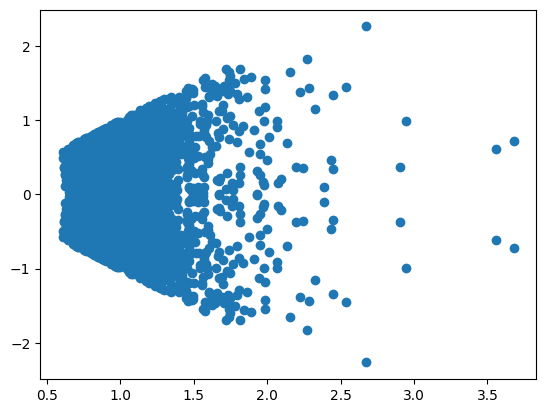

In [22]:
plt.scatter(particles[:, :, 0], particles[:, :, 1])